# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Muhammad Surya Ibrahim
- **Email:** ibrahimbtaz@gmail.com
- **ID Dicoding:** ibrahimibtaz

## Import Semua Packages/Library yang Digunakan

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
from google.colab import drive

print(tf.__version__)

2.19.0


## Data Preparation

### Data Loading

In [ ]:
# import pandas as pd
# import struct
# from PIL import Image
# import os

# drive_folder = '/content/drive/MyDrive/Proyek_UAS_Kanji/'
# csv_path = os.path.join(drive_folder, 'JLPT_kanji_master_list.csv')

# folder_etl_path = os.path.join(drive_folder, 'ETL8G')

# folder_tujuan = '/content/dataset_n5_siap_training/'
# os.makedirs(folder_tujuan, exist_ok=True)

# Baca CSV dan buat sub-folder untuk masing-masing 80 Kanji N5
# df = pd.read_csv(csv_path)
# n5_kanji_list = df[df['JLPT_level'] == 'N5']['kanji'].tolist()

# for kanji in n5_kanji_list:
#     os.makedirs(os.path.join(folder_tujuan, kanji), exist_ok=True)

# Fungsi Pembedah Memori Biner
# def ekstrak_etl8g(filepath):
#     record_size = 8199
#     kanji_terekstrak = 0

#     print(f"Memulai ekstraksi dari {os.path.basename(filepath)}...")
#     with open(filepath, 'rb') as f:
#         while True:
#             s = f.read(record_size)
#             if not s or len(s) < record_size:
#                 break

#             try:
#                 # Format unpack akurat untuk ETL8G
#                 r = struct.unpack('>2H8sI4B4H2B30x8128s11x', s)
#             except struct.error:
#                 continue

#             jis_code = r[1]
#             try:
#                 # Dekode format JIS ke karakter Jepang
#                 kanji_bytes = b'\x1b$B' + struct.pack('>H', jis_code) + b'\x1b(B'
#                 kanji_karakter = kanji_bytes.decode('iso2022_jp')
#             except Exception:
#                 continue

#             # Filter HANYA N5
#             if kanji_karakter in n5_kanji_list:
#                 img_data = r[14]
#                 img = Image.frombytes('F', (128, 127), img_data, 'bit', 4)
#                 img = img.convert('L') # Ubah ke grayscale
#                 img = img.resize((64, 64)) # OPTIMASI: Perkecil ke 64x64 untuk CNN

#                 nama_file = f"{kanji_karakter}_{os.path.basename(filepath)}_{kanji_terekstrak}.png"
#                 path_simpan = os.path.join(folder_tujuan, kanji_karakter, nama_file)
#                 img.save(path_simpan)

#                 kanji_terekstrak += 1

#     return kanji_terekstrak

# Eksekusi fungsinya untuk SEMUA file di dalam folder ETL8G
# total_semua_kanji = 0

# if os.path.exists(folder_etl_path) and os.path.isdir(folder_etl_path):
#     print("Folder ditemukan! Memulai proses batch extraction...\n")

#     # Ambil semua file di dalam folder dan urutkan
#     daftar_file = sorted(os.listdir(folder_etl_path))

#     for nama_file in daftar_file:
#         # Pastikan hanya memproses file yang berawalan "ETL8G_" (mengabaikan file aneh/hidden)
#         if nama_file.startswith("ETL8G_"):
#             path_lengkap_file = os.path.join(folder_etl_path, nama_file)
#             jumlah_ekstrak = ekstrak_etl8g(path_lengkap_file)
#             total_semua_kanji += jumlah_ekstrak

#     print(f"\n--- PROSES SELESAI ---")
#     print(f"Total keseluruhan Kanji N5 yang berhasil diekstrak: {total_semua_kanji} gambar!")
# else:
#     print(f"Folder {folder_etl_path} tidak ditemukan atau bukan sebuah direktori.")

In [2]:
local_zip = 'dataset_N5_bersih.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/')
zip_ref.close()

base_dir = 'dataset_n5_siap_training/'

kelas_kanji = os.listdir(base_dir)
print(f"Total kelas Kanji N5 yang siap dilatih: {len(kelas_kanji)} kelas")

Total kelas Kanji N5 yang siap dilatih: 80 kelas


### Data Preprocessing

#### Split Dataset

In [3]:
batch_size = 32
img_size = (64, 64)

print("1. Memuat Training Set (80% Data)...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    color_mode="grayscale",
    image_size=img_size,
    batch_size=batch_size
)

print("\n2. Memuat sisa 20% Data untuk dipecah lagi...")
val_ds_initial = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    color_mode="grayscale",
    image_size=img_size,
    batch_size=batch_size
)

val_batches = tf.data.experimental.cardinality(val_ds_initial)
val_ds = val_ds_initial.skip(val_batches // 2)
test_ds = val_ds_initial.take(val_batches // 2)

print("\n--- STATUS PEMBAGIAN DATA (Memenuhi Kriteria Dicoding) ---")
print(f"Jumlah batch pada Train Set      : {tf.data.experimental.cardinality(train_ds)}")
print(f"Jumlah batch pada Validation Set : {tf.data.experimental.cardinality(val_ds)}")
print(f"Jumlah batch pada Test Set       : {tf.data.experimental.cardinality(test_ds)}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

1. Memuat Training Set (80% Data)...
Found 12880 files belonging to 80 classes.
Using 10304 files for training.

2. Memuat sisa 20% Data untuk dipecah lagi...
Found 12880 files belonging to 80 classes.
Using 2576 files for validation.

--- STATUS PEMBAGIAN DATA (Memenuhi Kriteria Dicoding) ---
Jumlah batch pada Train Set      : 322
Jumlah batch pada Validation Set : 41
Jumlah batch pada Test Set       : 40


## Modelling

In [4]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    # Cek apakah akurasi latihan dan validasi sudah di atas 95%
    if(logs.get('accuracy') > 0.95 and logs.get('val_accuracy') > 0.95):
      print("\n\Akurasi > 95%. Menghentikan training!")
      self.model.stop_training = True

callbacks = myCallback()

# Membangun Arsitektur CNN
num_classes = len(kelas_kanji)

model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(64, 64, 1)),

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Flatten(),
  layers.Dropout(0.5), # Mencegah Overfitting
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
])

model.summary()

# Kompilasi Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Memulai Proses Training
epochs = 20

print("\n🚀 Memulai proses training...")
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[callbacks]
)

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_22411/2207728425.py:5: SyntaxWarning: invalid escape sequence '\A'
  print("\n\Akurasi > 95%. Menghentikan training!")
/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80)             │        10,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,126,416 (8.11 MB)

 Trainable params: 2,126,416 (8.11 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Memulai proses training...
Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 70s 205ms/step - accuracy: 0.3023 - loss: 2.9668 - val_accuracy: 0.6196 - val_loss: 1.4745
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 66s 205ms/step - accuracy: 0.7052 - loss: 1.1320 - val_accuracy: 0.7978 - val_loss: 0.8208
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 80s 200ms/step - accuracy: 0.8211 - loss: 0.6664 - val_accuracy: 0.8472 - val_loss: 0.5775
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 82s 201ms/step - accuracy: 0.8765 - loss: 0.4551 - val_accuracy: 0.8719 - val_loss: 0.5008
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 64s 200ms/step - accuracy: 0.8978 - loss: 0.3504 - val_accuracy: 0.8858 - val_loss: 0.4634
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 83s 200ms/step - accuracy: 0.9108 - loss: 0.2899 - val_accuracy: 0.8966 - val_loss: 0.4178
Epoch 7/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 64s 200ms/step - accuracy: 0.9266 - loss: 0.2411 - val_accuracy: 0.9113 - val_loss: 0.3938
Epoch 8/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 64s 198ms/ste

## Evaluasi dan Visualisasi

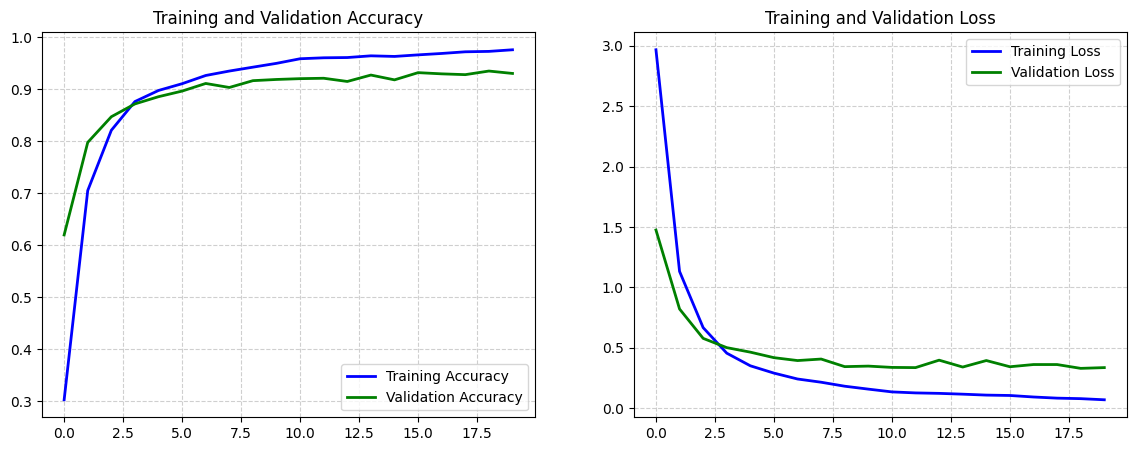


--- HASIL UJIAN AKHIR (TEST SET) ---
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9352 - loss: 0.3066
Akurasi Test Set: 93.52%


In [5]:
import matplotlib.pyplot as plt

# 1. Mengambil data riwayat belajar AI dari variabel 'history'
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Menyesuaikan jumlah putaran (epoch) yang sebenarnya berjalan
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# 2. Membuat Grafik Akurasi (Tingkat Kecerdasan)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='green', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Membuat Grafik Loss (Tingkat Kesalahan)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='green', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# 4. Ujian Akhir menggunakan Test Set (Data yang 100% belum pernah dilihat AI)
print("\n--- HASIL UJIAN AKHIR (TEST SET) ---")
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Akurasi Test Set: {test_accuracy * 100:.2f}%")

## Konversi Model

In [6]:
# Install modul TensorFlow.js (Butuh beberapa detik)
!pip install tensorflowjs

import tensorflow as tf
import tensorflowjs as tfjs
import pathlib
import os

print("\n--- MEMULAI KONVERSI MODEL ---")

# 1. Konversi ke format SavedModel
saved_model_dir = 'saved_model/'
tf.saved_model.save(model, saved_model_dir)
print("✅ Berhasil: SavedModel (Tersimpan di folder 'saved_model/')")

# 2. Konversi ke format TF-Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_dir = pathlib.Path('tflite/')
tflite_dir.mkdir(parents=True, exist_ok=True)
tflite_model_file = tflite_dir / 'model.tflite'
tflite_model_file.write_bytes(tflite_model)

# Menyimpan file label.txt untuk TF-Lite (Opsional tapi sangat disarankan)
with open(tflite_dir / 'label.txt', 'w') as f:
    f.write('\n'.join(kelas_kanji))
print("✅ Berhasil: TF-Lite (Tersimpan di folder 'tflite/')")

# 3. Konversi ke format TFJS
tfjs_dir = 'tfjs_model/'
tfjs.converters.save_keras_model(model, tfjs_dir)
print("✅ Berhasil: TFJS (Tersimpan di folder 'tfjs_model/')")

print("\n🎉 SEMUA KONVERSI SELESAI!")


--- MEMULAI KONVERSI MODEL ---
✅ Berhasil: SavedModel (Tersimpan di folder 'saved_model/')
Saved artifact at '/tmp/tmpuj3b3fla'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 80), dtype=tf.float32, name=None)
Captures:
  140715610414672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140715610416208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140715610416976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140715610417360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140715626735248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140715610416592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140715610418128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140715610414288: TensorSpec(shape=(), dtype=tf.resource, name=None)


✅ Berhasil: TF-Lite (Tersimpan di folder 'tflite/')
failed to lookup keras version from the file,
    this is likely a weight only file
✅ Berhasil: TFJS (Tersimpan di folder 'tfjs_model/')

🎉 SEMUA KONVERSI SELESAI!


## Inference (Optional)

Memuat model dari format TF-Lite...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


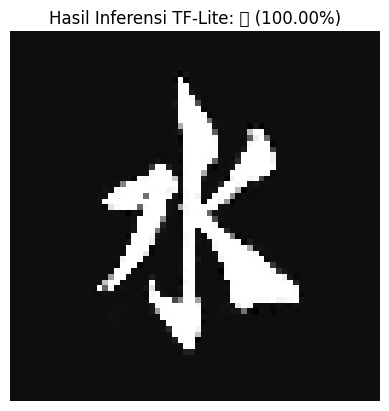


[INFO] AI berhasil mengeksekusi gambar menggunakan berkas TF-Lite.
Karakter terdeteksi: 水


In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Memuat model dari format TF-Lite (Memenuhi saran Bintang 5 Dicoding)
print("Memuat model dari format TF-Lite...")
interpreter = tf.lite.Interpreter(model_path="tflite/model.tflite")
interpreter.allocate_tensors()

# Mendapatkan detail input dan output dari TF-Lite
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 2. Ambil daftar kelas dari folder dataset
base_dir = '/content/dataset_n5_siap_training/'
class_names = sorted(os.listdir(base_dir))

# 3. Tentukan letak gambar tes tulisan tanganmu
path_gambar_tes = '/content/tes_kanji.png'

if os.path.exists(path_gambar_tes):
    # Preprocessing gambar agar sesuai standar saat training
    img = tf.keras.utils.load_img(path_gambar_tes, target_size=(64, 64), color_mode="grayscale")
    img_array = tf.keras.utils.img_to_array(img)
    img_array = 255.0 - img_array  # Inversi warna (Latar hitam, tinta putih)
    img_array = np.expand_dims(img_array, axis=0)

    # PERHATIAN: TF-Lite sangat ketat dengan tipe data, wajib diubah ke float32
    img_array = img_array.astype(np.float32)

    # 4. Melakukan prediksi menggunakan TF-Lite Interpreter
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    predictions = interpreter.get_tensor(output_details[0]['index'])

    tebakan_index = np.argmax(predictions[0])
    kanji_tebakan = class_names[tebakan_index]
    persentase_yakin = 100 * np.max(predictions[0])

    # 5. Menampilkan visualisasi hasil inferensi
    plt.imshow(img_array[0].squeeze(), cmap='gray')
    plt.title(f"Hasil Inferensi TF-Lite: {kanji_tebakan} ({persentase_yakin:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"\n[INFO] AI berhasil mengeksekusi gambar menggunakan berkas TF-Lite.")
    print(f"Karakter terdeteksi: {kanji_tebakan}")
else:
    print(f"[PENTING] File '{path_gambar_tes}' tidak ditemukan.")
    print("Silakan upload ulang file gambar tulisan tangan persegi kamu ke menu Files Colab dengan nama 'tes_kanji.png' lalu jalankan ulang cell ini.")